# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muchammad Taufik
- **Email:** muchammadtaufik.22010@mhs.unesa.ac.id
- **ID Dicoding:** muchammad_taufik

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh cuaca terhadap jumlah pengguna di hari biasa(weekday)?
- Bagaimana hubungan antara jumlah pengguna sepeda pada setiap hari?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [4]:
#Read Data hour_df
hour_df = pd.read_csv("hour.csv")
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [5]:
#Read Data day_df
day_df = pd.read_csv("day.csv")
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


**Insight:**
- Mendapatkan informasi tentang data rental sepeda pada setiap jam
- Mendapatkan informasi tentang data rental sepeda pada setiap hari

### Assessing Data

In [6]:
# Assesing Data hour_df
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
# Assesing Data hour_df
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- Pada data hour_df terdapat kesalahan tipe data pada kolom dteday
- Pada data day_df terdapat kesalahan tipe data pada kolom dteday

### Cleaning Data

In [8]:
#Mengubah tipe data dteday pada hour_df
column = "dteday"
hour_df[column] = pd.to_datetime(hour_df[column])

In [9]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [10]:
#Mengubah tipe data dteday pada day_df
column = "dteday"
day_df[column] = pd.to_datetime(day_df[column])

In [11]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Memperbaiki kesalahan tipe data pada tabel hour_df untuk kolom dteday
- Memperbaiki kesalahan tipe data pada tabel day_df untuk kolom dteday

## Exploratory Data Analysis (EDA)

### Explore Data hour_df

In [12]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**Melihat korelasi antara setiap jam dengan total pengguna sepeda**

In [13]:
hour_df.groupby(by="hr").agg({
    "instant": "nunique",
    "cnt": ["sum", "max", "min", "mean", "std"]
})

instant     cnt                                 
   nunique     sum  max min        mean         std
hr                                                 
0      726   39130  283   2   53.898072   42.307910
1      724   24164  168   1   33.375691   33.538727
2      715   16352  132   1   22.869930   26.578642
3      697    8174   79   1   11.727403   13.239190
4      697    4428   28   1    6.352941    4.143818
5      717   14261   66   1   19.889819   13.200765
6      725   55132  213   1   76.044138   55.084348
7      727  154171  596   1  212.064649  161.441936
8      727  261001  839   5  359.011004  235.189285
9      727  159438  426  14  219.309491   93.703458
10     727  126257  539   8  173.668501  102.205413
11     727  151320  663  10  208.143054  127.495536
12     728  184414  776   3  253.315934  145.081134
13     729  184919  760  11  253.661180  148.107657
14     729  175652  750  12  240.949246  147.271574
15     729  183149  750   7  251.233196  144.632541
16     730  227748  783  11  311.983562  148.682618
17     730  336860  976  15  461.452055  232.656611
18     728  309772  977  23  425.510989  224.639304
19     728  226789  743  11  311.523352  161.050359
20     728  164550  567  11  226.030220  119.670164
21     728  125445  584   6  172.314560   89.788893
22     728   95612  502   9  131.335165   69.937782
23     728   63941  256   2   87.831044   50.846889

**Membuat kolom pengelompokkan waktu berdasarkan pembagian jam**

In [14]:
hour_df["hr_group"] = hour_df.hr.apply(
    lambda x: "Pagi Hari" if x >= 4 and x < 11
    else ("Siang Hari" if x >= 11 and x < 16
    else ("Sore Hari" if x >= 16 and x < 21
    else "Malam Hari"))
)

hour_df.groupby(by="hr_group").instant.nunique().sort_values(ascending=False)


,instant
hr_group,
Pagi Hari,5047
Malam Hari,5046
Sore Hari,3644
Siang Hari,3642


**Menampilkan korelasi antara pengelompokkan waktu dengan total pengguna sepeda**

In [15]:
hour_df.groupby(by="hr_group").agg({
    "instant": "nunique",
    "cnt": ["sum", "max", "min", "mean", "std"]})

instant      cnt                                 
           nunique      sum  max min        mean         std
hr_group                                                    
Malam Hari    5046   372818  584   1   73.883868   76.679566
Pagi Hari     5047   774688  839   1  153.494749  169.079938
Siang Hari    3642   879454  776   3  241.475563  143.693506
Sore Hari     3644  1265719  977  11  347.343304  201.588535

### Explor Data day_df

In [16]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Melihat korelasi antara cuaca dengan total pengguna**

In [17]:
day_df.groupby(by="weathersit").agg({
    "instant": "nunique",
    "cnt": ["sum", "max", "min", "mean", "std"]
})

instant      cnt                                     
           nunique      sum   max  min         mean          std
weathersit                                                      
1              463  2257952  8714  431  4876.786177  1879.483989
2              247   996858  8362  605  4035.862348  1809.109918
3               21    37869  4639   22  1803.285714  1240.284449

**Melihat korelasi antara cuaca, hari biasa(weekday) dan total pengguna sepeda**

In [18]:
day_df.groupby(by=["weathersit", "weekday"]).agg({
    "instant": "nunique",
    "cnt": ["sum", "max", "min", "mean", "std"]
})

instant     cnt                                      
                   nunique     sum   max   min         mean          std
weathersit weekday                                                      
1          0            74  321787  8227   754  4348.472973  1956.689693
           1            66  296053  7525  1317  4485.651515  1714.410385
           2            62  309374  7767  1450  4989.903226  1715.748488
           3            64  341397  8173  1162  5334.328125  1752.419154
           4            67  336000  7804   431  5014.925373  1956.672108
           5            63  319957  8167  1421  5078.682540  1758.937049
           6            67  333384  8714   981  4975.880597  2112.241797
2          0            30  121213  7410   605  4040.433333  1584.224289
           1            37  156663  7013   920  4234.135135  1828.656963
           2            38  148185  7273   683  3899.605263  1803.973550
           3            33  121346  7572  1526  3677.151515  1756.893496
           4            34  145245  7509  1807  4271.911765  1633.869164
           5            41  167833  8362  1167  4093.487805  1910.750142
           6            34  136373  7852   959  4010.970588  2133.330779
3          0             1    1027  1027  1027  1027.000000          NaN
           1             2    2787  2765    22  1393.500000  1939.593901
           2             4   11550  4639  1607  2887.500000  1268.211470
           3             7   10305  2424   441  1472.142857   892.136654
           4             3    4150  1842   623  1383.333333   663.130706
           6             4    8050  4459   627  2012.500000  1771.230363

**Insight:**
- Pada eksplorasi hour_df melihat korelasi antara pengelempokkan waktu didapat puncak dari pengguna sepeda terjadi pada sore hari dengan rata-rata 201,5885
- Pada eksplorasi day_df melihat korelasi antara cuaca dan hari biasa(weekday) didapat bahwa pada cuaca 3 jumlah pengguna sepeda paling sedikit dan pengguna sepeda paling banyak terdapat di cuaca 1

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh cuaca terhadap jumlah total pengguna di hari biasa(weekday)?

In [19]:
weather_weekday_df = day_df[day_df["weekday"] == 0].groupby(["weathersit"]).cnt.sum().sort_values(ascending=False).reset_index()
# Karena tidak ada cuaca 4 maka akan kita tambahkan cuaca 4 dengan cnt bernilai 0.
if not (weather_weekday_df['weathersit'] == 4).any():
    new_row = pd.DataFrame({"weathersit": [4], "cnt": [0]})
    weather_weekday_df = pd.concat([weather_weekday_df, new_row], ignore_index=True)

weather_weekday_df.rename(columns={
    "weathersit": "weather_index", "cnt": "user_count"
}, inplace=True)

weather_weekday_df

,weather_index,user_count
0,1,321787
1,2,121213
2,3,1027
3,4,0


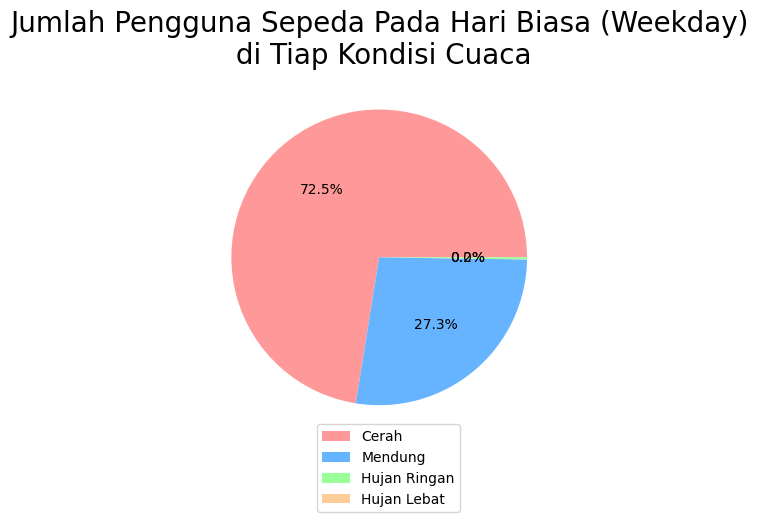

In [30]:
fig, ax = plt.subplots()

# Labels untuk pie chart
labels_detail = [
    'Cerah',
    'Mendung',
    'Hujan Ringan',
    'Hujan Lebat'
]

# Ukuran setiap bagian pie chart
size = weather_weekday_df["user_count"]

# Menggunakan daftar warna pastel
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

# Membuat pie chart
pie = plt.pie(size, startangle=0, colors=colors, autopct='%1.1f%%')

# Menambahkan judul
title = plt.title("Jumlah Pengguna Sepeda Pada Hari Biasa (Weekday)\n di Tiap Kondisi Cuaca", fontsize=20)
title.set_ha("center")

# Menambahkan legenda
plt.legend(
    pie[0],
    labels_detail,
    bbox_to_anchor=(0.65, -0.05),
    loc="lower right",
    bbox_transform=plt.gcf().transFigure
)

# Menampilkan chart
plt.show()


### Pertanyaan 2: Bagaimana hubungan antara jumlah total pengguna sepeda pada setiap hari?

In [24]:
HourGroup_df = hour_df.groupby(by="hr_group").cnt.sum().reset_index()
HourGroup_df.rename(columns={
    "hr_group": "hour_group",
    "cnt": "users_count"
}, inplace=True)
HourGroup_df

,hour_group,users_count
0,Malam Hari,372818
1,Pagi Hari,774688
2,Siang Hari,879454
3,Sore Hari,1265719


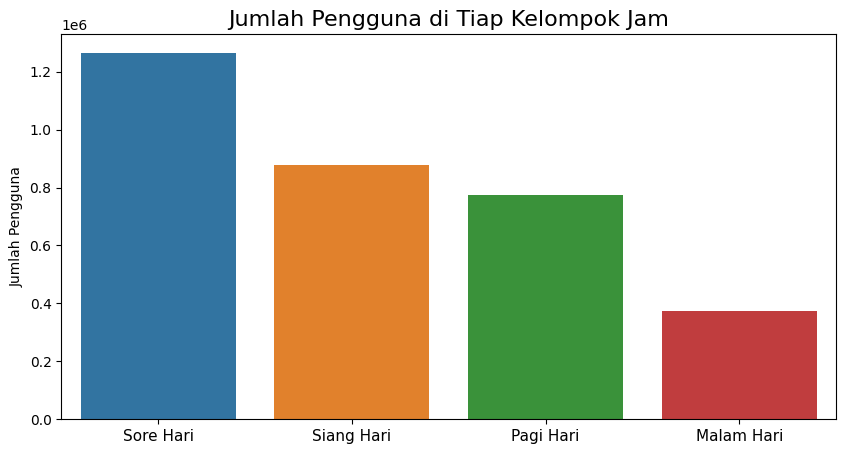

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    y="users_count",
    x="hour_group",
    hue="hour_group",
    data=byHourGroup_df.sort_values(by="users_count", ascending=False),
    legend=False
)
plt.title("Jumlah Pengguna di Tiap Kelompok Jam", loc="center", fontsize=16)
plt.ylabel("Jumlah Pengguna")
plt.xlabel(None)
plt.tick_params(axis='x', labelsize=11)
plt.show()


**Insight:**
- Pada visualisasi pertanyaan pertama terlihat pada cuaca cerah banyak orang yang menggunakan jasa rental sepeda sedangkan pada cuaca hujan lebat tidak ada orang yang menggunakan jasa rental sepeda.
- Pada visualisasi pertanyaan kedua terlihat bahwa jumlah pengguna tertinggi terjadi pada sore hari dan jumlah pengguna paling sedikit terjadi pada malam hari.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 : Jadi dapat disimpulkan bahwa cuaca sangat berpengaruh terhadap jumlah pengguna sepeda pada weekday. Salah satu faktor pendukung dapat dilihat pada visualisasi Jumlah Pengguna Sepeda Pada Hari Biasa (Weekday) di Tiap Kondisi Cuaca dimana jumlah pengguna sepeda saat cuaca cerah lebih besar dibandingkan dengan cuaca hujan lebat. Sehingga dapat disimpulkan semakin baik cuaca akan semakin banyak pengguna sepeda dan sebaliknya cuaca buruk membuat jumlah pengguna sepeda sangat kecil.
- Conclution pertanyaan 2 : Jadi dapat disimpulkan bahwa pengguna sepeda pada hari biasa(weekday) di sore hari memiliki jumlah yang sangat besar dibandingkan pada pembagian waktu yang lain yaitu pagi, siang dan sore hari.